In [2]:
from PIL import Image
import numpy as np
import pandas as pd
import os
print(os.listdir("input"))

['usps.h5']


In [3]:
import h5py
from functools import reduce

def getUspDataSet(path):
    with h5py.File(path, 'r') as hf:
        train = hf.get('train')
        x_Train = train.get("data")[:]
        y_Train = train.get("target")[:]
        test = hf.get('test')
        x_Test = test.get("data")[:]
        y_Test = test.get("target")[:]
    return x_Train, y_Train, x_Test, y_Test

In [4]:
import matplotlib.pyplot as plt

def plot_image(image):
    fig = plt.gcf()
    fig.set_size_inches(2, 2)
    plt.imshow(image, cmap='binary')
    plt.show()

In [5]:
import matplotlib.pyplot as plt

def plot_images_labels_prediction(images,labels,
                                  prediction,idx,num=10):
    fig = plt.gcf()
    fig.set_size_inches(12, 14)
    if num>25: num=25
    for i in range(0, num):
        ax=plt.subplot(5,5, 1+i)
        ax.imshow(images.iloc[idx, np.arange(0, 256)].values.reshape([16, 16]), cmap='binary')
        title= "label=" +str(labels.iloc[idx,0])
        if len(prediction)>0:
            title+=",predict="+str(prediction.iloc[idx,0])

        ax.set_title(title,fontsize=10)
        ax.set_xticks([]);ax.set_yticks([])
        idx+=1
    plt.show()

In [6]:
# 2-norm
def norm2 (a, ak):
    return np.linalg.norm(a-ak, 2)

In [7]:
x_Train, y_Train, x_Test, y_Test = getUspDataSet("./input/usps.h5")
print("training set (16x16) : %d 張" % x_Train.shape[0])
print("testing set (16x16) : %d 張" % x_Test.shape[0])

training set (16x16) : 7291 張
testing set (16x16) : 2007 張


In [8]:
x_Train_data = pd.concat([pd.DataFrame(x_Train),pd.DataFrame(y_Train, columns=['digital'])], axis=1)
x_Test_data = pd.concat([pd.DataFrame(x_Test),pd.DataFrame(y_Test, columns=['digital'])], axis=1)

In [9]:
x_Train_data.iloc[0, np.arange(0, 256)].values.reshape([16, 16])

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.18450001, 0.93099999, 0.4165    ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.00400001, 0.64849997, 1.        , 0.65350002,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.29500002, 1.        , 0.99300003, 0.2175    ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.15849999, 0.91250002, 1.        , 0.78100002, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.03099999,
        0.76999998, 1.        , 

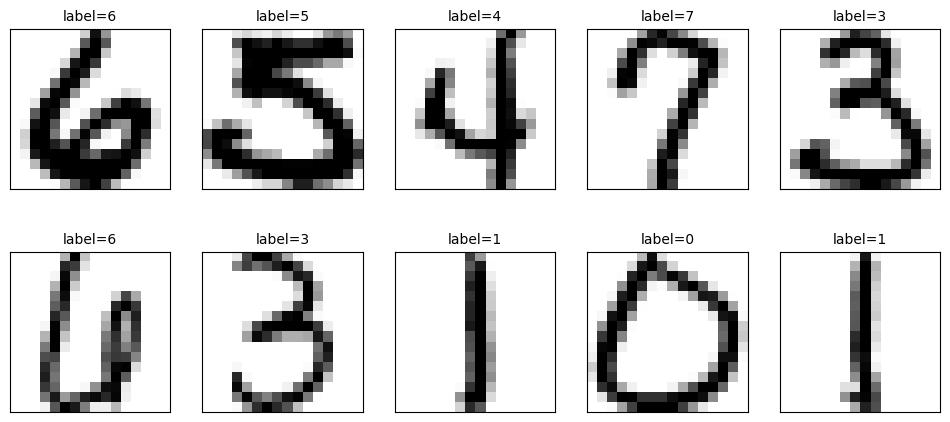

In [10]:
plot_images_labels_prediction(x_Train_data.loc[:,np.arange(0, 256)], x_Train_data.loc[:,['digital']],[],0,)

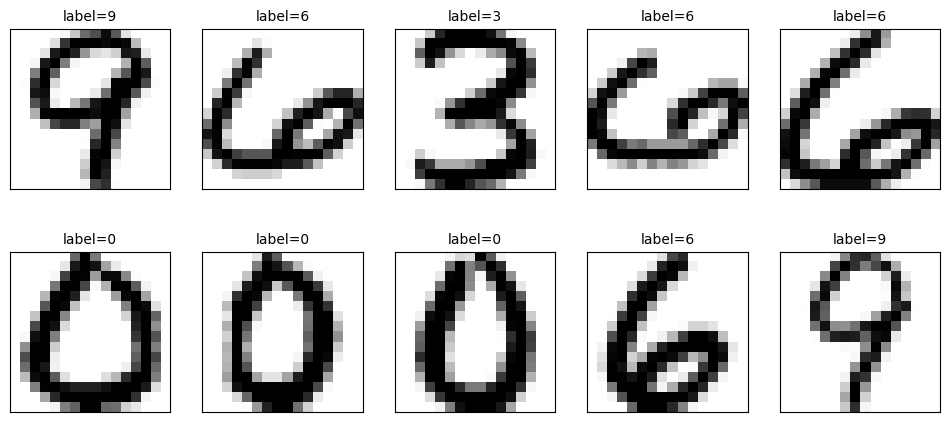

In [11]:
plot_images_labels_prediction(x_Test_data.loc[:,np.arange(0, 256)], x_Test_data.loc[:,['digital']],[],0,)

In [12]:
feature_names = np.array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'Total'])

table = np.zeros((2, 11))

for i in range(11):
    table[0][i] = x_Train_data[x_Train_data['digital'] == i].shape[0]
    table[1][i] = x_Test_data[x_Test_data['digital'] == i].shape[0]
    if i == 10:
        table[0][i] = x_Train_data.shape[0]
        table[1][i] = x_Test_data.shape[0]

pd.DataFrame(table, columns=feature_names)

,0,1,2,3,4,5,6,7,8,9,Total
0,1194.0,1005.0,731.0,658.0,652.0,556.0,664.0,645.0,542.0,644.0,7291.0
1,359.0,264.0,198.0,166.0,200.0,160.0,170.0,147.0,166.0,177.0,2007.0


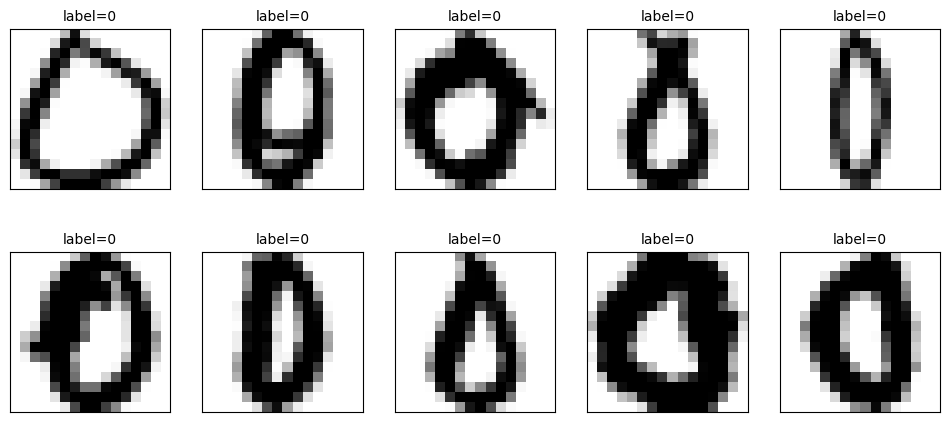

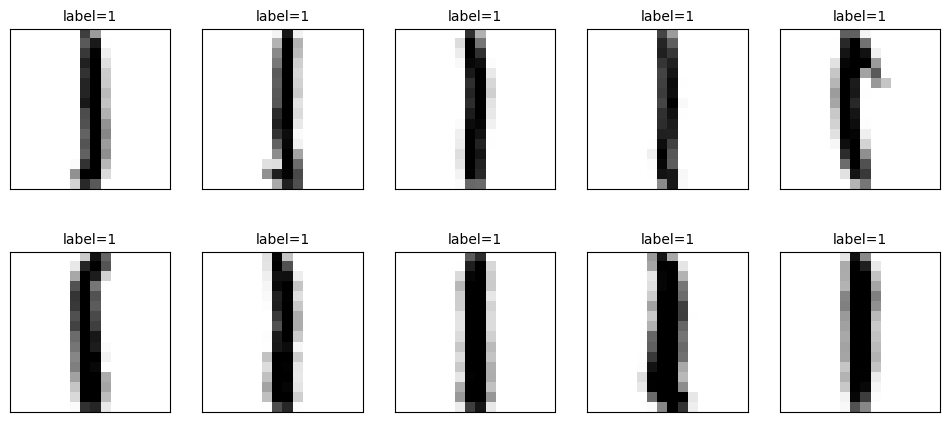

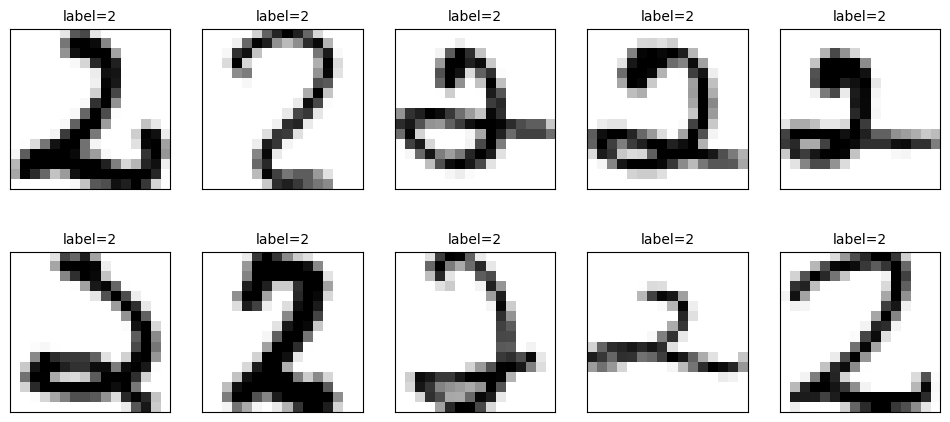

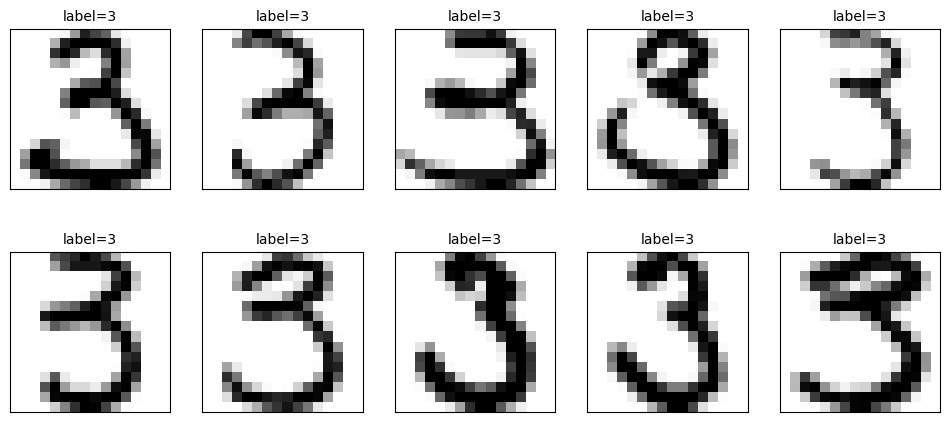

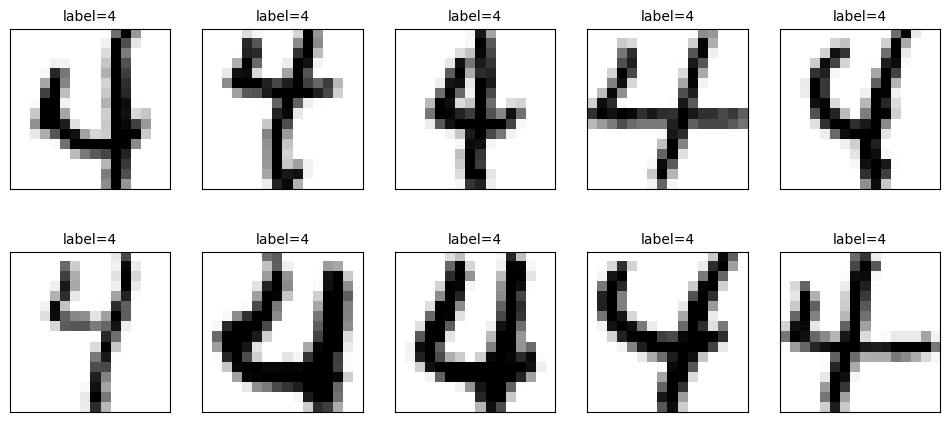

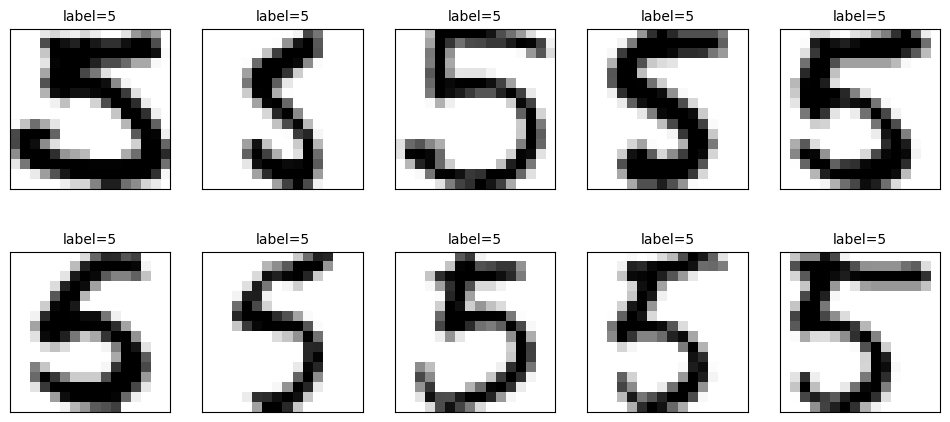

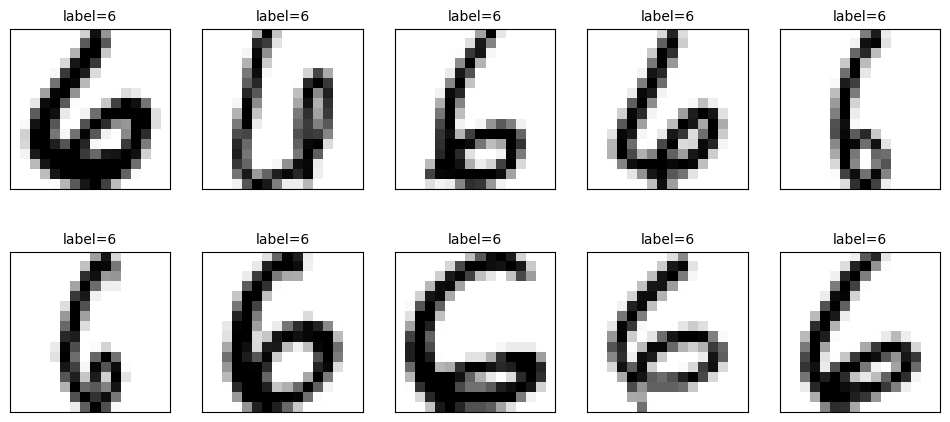

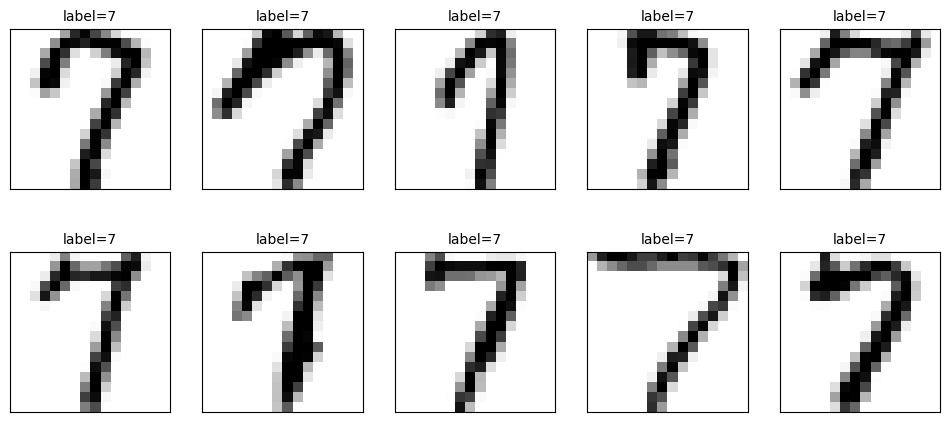

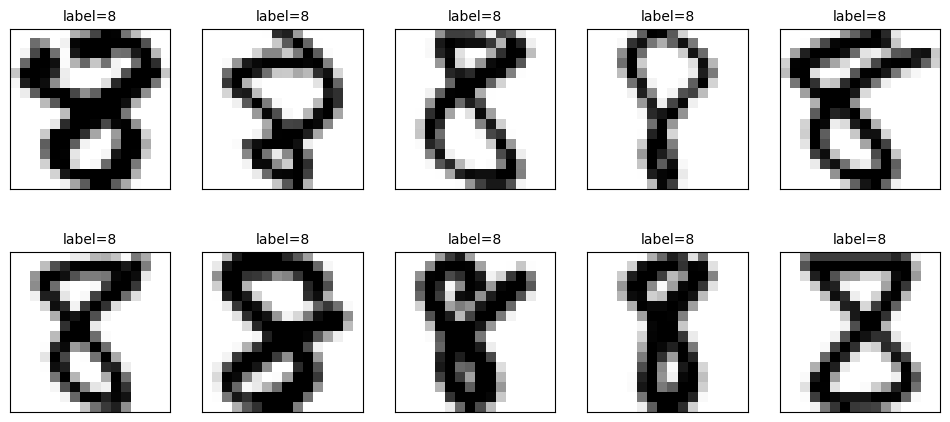

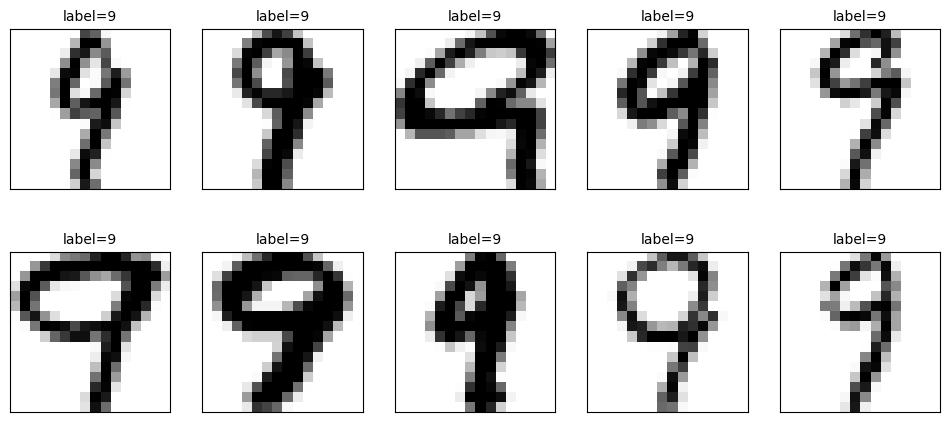

In [13]:
for i in range(0,10):
    plot_images_labels_prediction(x_Train_data[x_Train_data['digital'] == i].loc[:,np.arange(0, 256)], x_Train_data[x_Train_data['digital'] == i].loc[:,['digital']],[],0,)

# Handwritten Digits and a Simple Algorithm

# Classification Using higher order SVD (HOSVD)

In [14]:
!pip install tensorly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 43.2 MB/s eta 0:00:00


In [15]:
!pip list | grep tensor

pytensor                              2.30.3
safetensors                           0.5.3
tensorboard                           2.18.0
tensorboard-data-server               0.7.2
tensorflow                            2.18.0
tensorflow-datasets                   4.9.8
tensorflow_decision_forests           1.11.0
tensorflow-hub                        0.16.1
tensorflow-io-gcs-filesystem          0.37.1
tensorflow-metadata                   1.17.1
tensorflow-probability                0.25.0
tensorflow-text                       2.18.1
tensorly                              0.9.0
tensorstore                           0.1.74


In [16]:
import numpy as np
import torch as tc
import tensorly as tl
from tensorly.decomposition import tucker

In [17]:
def getSandUList(X_Date):
    X_Date = X_Date.astype('float32') # 0~255 to 0~1
    X_Date = X_Date.reshape((len(X_Date), np.prod(X_Date.shape[1:]))) # 2D to 1d

    x_list = []

    #　按數字類別分組，x_list　包含 10 個元素，每個元素是一個數字類別的所有樣本
    for k in range(10):
        components = np.where(y_Train == k)[0]
        x_list.append(x_Train[components, :])

    S_list = []
    U_list = []

    # 每個數字類別（0-9）
    for k in range(10):

        # 三階張量 tensor，形狀為 (16, 16, n)，其中 n 是該類別的樣本數
        tensor = np.zeros((16, 16, x_list[k].shape[0]))
        for i in range(x_list[k].shape[0]):
            tensor[:,:,i] = x_list[k][i][:].reshape([16, 16])

        # 設置 tensorly 後端為 numpy（可選）
        tl.set_backend('numpy')

        # 將輸入張量轉換為 tensorly 張量
        tensor_tl = tl.tensor(tensor)

        # 執行 Tucker 分解
        # 注意：tensorly 的 tucker 函數返回的是 (core_tensor, factors) 元組
        tucker_result = tucker(tensor_tl, rank=tensor.shape)

        # 獲取核心張量和因子矩陣
        S = tucker_result[0]  # 核心張量
        U = tucker_result[1]  # 因子矩陣列表

        S_list.append(S)
        U_list.append(U)

    return S_list, U_list

def hosvdAlgorithm (x_Data, y_Data, S_list, U_list, basis):

    x_Data = x_Data.astype('float32')  # 0~255 to 0~1
    x_Data = x_Data.reshape((len(x_Data), np.prod(x_Data.shape[1:]))) # 2D to 1D

    result_mse = []
    result_residual = []

    # 基於不同基底數量的分類
    for r in range(basis):
        n_Data = x_Data.shape[0]
        y_predict = np.ones((n_Data)) # 存儲預測的類別
        result_single = np.ones(n_Data) # 存儲最小殘差值

        # 對每個測試樣本進行分類
        for i in range(0, n_Data):
            Z = x_Data[i][:].reshape([16, 16]) # 樣本捏回 16×16 的矩陣 Z
            residual_list = np.ones((10)) # 存儲與每個數字類別的殘差

            # 計算與每個數字類別的殘差
            for d in range(10):
                U1, U2, U3 = U_list[d]
                S = S_list[d]

                Sigma = np.zeros((16, 16)) # 初始化重構矩陣 Sigma

                # 用前 r+1 個基底進行重構
                for j in range(r+1):
                    Aj = U1.dot(S[:,:,j]).dot(U2.T) # Aj = U1 · S[:,:,j] · U2^T
                    Cj = np.tensordot(Z, Aj)/np.tensordot(Aj, Aj) # Cj = <Z, Aj> / <Aj, Aj>
                    Sigma = Sigma + (Cj*Aj)

                G = np.linalg.norm(Z-Sigma, "fro") #　殘差

                residual_list[d] = G

            y_predict[i] = np.argmin(residual_list)

            # 記錄最終結果
            if r == basis-1:
                result_residual.append(residual_list)
                result_single[i] = np.amin(residual_list)

        result_mse.append(np.mean((y_Data/1.0 - y_predict/1.0) ** 2)) # 均方誤差

    # 整理結果
    x_Data_list = pd.concat([pd.DataFrame(x_Data),pd.DataFrame(y_Data, columns=['actual'])], axis=1)
    result_list = pd.concat([x_Data_list, pd.DataFrame(y_predict, columns=['prediction'])], axis=1)
    result_list = pd.concat([result_list, pd.DataFrame(result_single, columns=['residual'])], axis=1)
    result_prediction = result_list[result_list['prediction'] == result_list['actual']].shape[0]/result_list.shape[0]

    return result_list, y_predict, result_prediction, result_residual, result_mse

In [18]:
x_Train, y_Train, x_Test, y_Test = getUspDataSet("./input/usps.h5")
print("training set (16x16) : %d 張" % x_Train.shape[0])
print("testing set (16x16) : %d 張" % x_Test.shape[0])

training set (16x16) : 7291 張
testing set (16x16) : 2007 張


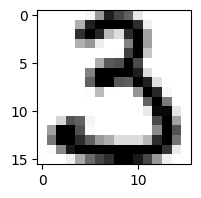

In [19]:
x_Train.shape
plot_image(x_Train[4][:].reshape([16, 16]))

In [20]:
components = np.where(y_Train == 3)[0]
components
x_Train_3 = x_Train[components, :]
y_Train_3 = np.full(x_Train_3.shape[0],3)

x_Train_3.shape

(658, 256)

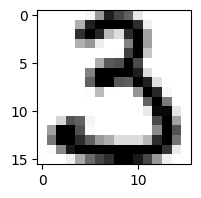

In [21]:
tensor = np.zeros((16, 16, x_Train_3.shape[0]))

for i in range(x_Train_3.shape[0]):
    tensor[:,:,i] = x_Train_3[i][:].reshape([16, 16])

plot_image(tensor[:,:,0])

In [22]:
# 設置 tensorly 後端為 numpy（可選）
tl.set_backend('numpy')

# 將輸入張量轉換為 tensorly 張量
tensor_tl = tl.tensor(tensor)

# 執行 Tucker 分解
# 注意：tensorly 的 tucker 函數返回的是 (core_tensor, factors) 元組
tucker_result = tucker(tensor_tl, rank=tensor.shape)

# 獲取核心張量和因子矩陣
S = tucker_result[0]  # 核心張量
U = tucker_result[1]  # 因子矩陣列表

In [23]:
S.shape, U[0].shape, U[1].shape, U[2].shape

((16, 16, 658), (16, 16), (16, 16), (658, 658))

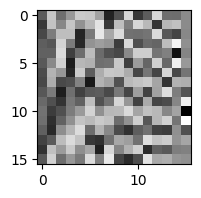

In [24]:
plot_image(U[0])

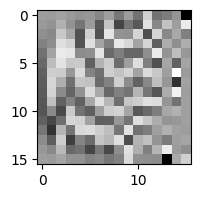

In [25]:
plot_image(U[1])

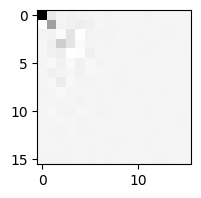

In [26]:
plot_image(S[:,:,0])

In [27]:
A_hosvd = tc.einsum("abc,da,eb,fc->def", tc.as_tensor(S), tc.as_tensor(U[0]), tc.as_tensor(U[1]), tc.as_tensor(U[2]))

In [28]:
hosvd_tensor = tc.Tensor.cpu(A_hosvd).detach().numpy()[:,:,:]

In [29]:
tensor.shape, hosvd_tensor.shape

((16, 16, 658), (16, 16, 658))

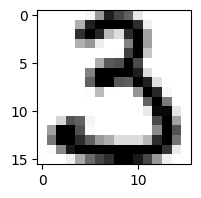

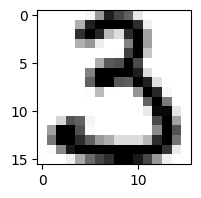

In [30]:
plot_image(tensor[:,:,0])
plot_image(hosvd_tensor[:,:,0])

In [31]:
error = np.linalg.norm(tensor - hosvd_tensor)
error

np.float64(4.564121840633578e-13)

In [32]:
x_Train, y_Train, x_Test, y_Test = getUspDataSet("./input/usps.h5")
print("training set (16x16) : %d 張" % x_Train.shape[0])
print("testing set (16x16) : %d 張" % x_Test.shape[0])

training set (16x16) : 7291 張
testing set (16x16) : 2007 張


In [33]:
S_list, U_list = getSandUList(x_Train)

In [34]:
U1, U2, U3 = U_list[3]
S = S_list[2]
S.shape, U1.shape, U2.shape, U3.shape

((16, 16, 731), (16, 16), (16, 16), (658, 658))

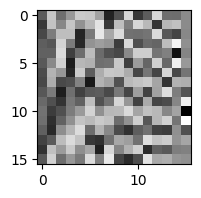

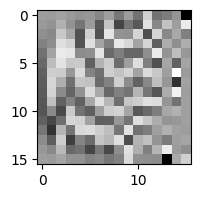

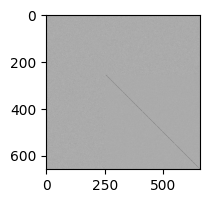

In [35]:
plot_image(U1)
plot_image(U2)
plot_image(U3)

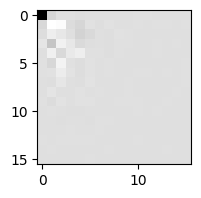

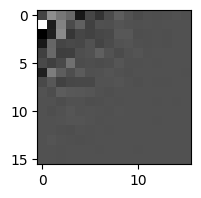

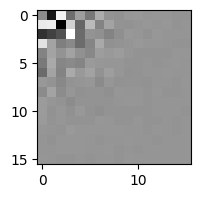

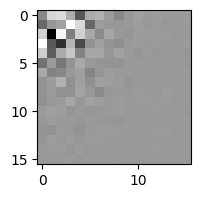

In [36]:
plot_image(S[:,:,0])
plot_image(S[:,:,1])
plot_image(S[:,:,2])
plot_image(S[:,:,3])

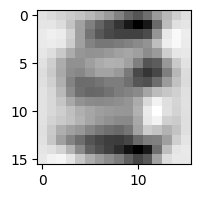

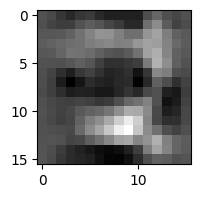

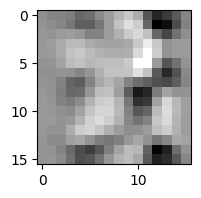

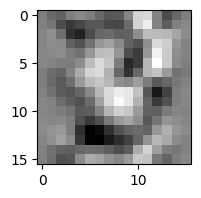

In [37]:
for i in range(4):
  Aj = U1.dot(S[:,:,i]).dot(U2.T)
  plot_image(Aj)

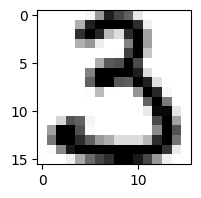

In [38]:
Z = x_Train[4][:].reshape([16, 16])
plot_image(Z)

In [39]:
 Cj = np.tensordot(Z, Aj)/np.tensordot(Aj, Aj)
 Cj

np.float64(0.028984772412874768)

In [40]:
G = np.linalg.norm(Z-Cj*Aj,"fro")
G

np.float64(7.75725641472054)

In [41]:
U1, U2, U3 = U_list[2]
S = S_list[2]
S.shape, U1.shape, U2.shape, U3.shape

((16, 16, 731), (16, 16), (16, 16), (731, 731))

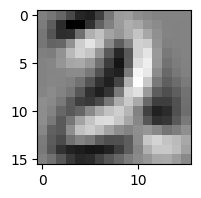

In [42]:
Aj = U1.dot(S[:,:,3]).dot(U2.T)
plot_image(Aj)

In [43]:
 Cj = np.tensordot(Z, Aj)/np.tensordot(Aj, Aj)
 Cj

np.float64(0.03371456395196712)

In [44]:
G = np.linalg.norm(Z-Cj*Aj, "fro")
G

np.float64(7.732825117183781)

In [45]:
result_Train_list, y_Train_predict, result_Train_predict, result_Train_residual, result_Train_mse = hosvdAlgorithm(x_Train, y_Train, S_list, U_list, 12)

In [46]:
result_Train_predict

0.9728432313811548

In [47]:
result_Train_residual[7290]

array([4.84818551, 1.36282795, 4.34496107, 4.81053855, 3.00884076,
       4.8572794 , 3.99766541, 4.21071436, 2.75126265, 3.77235222])

In [48]:
result_Train_mse

[np.float64(3.198052393361679),
 np.float64(1.4978740913454944),
 np.float64(1.2891235770127554),
 np.float64(0.9462350843505692),
 np.float64(0.7939925936085585),
 np.float64(0.7944040597997531),
 np.float64(0.7104649567960499),
 np.float64(0.5841448360993005),
 np.float64(0.5739953367164998),
 np.float64(0.5336716499794267),
 np.float64(0.5542449595391579),
 np.float64(0.5044575504046084)]

Text(0.5, 0, 'number of basis')

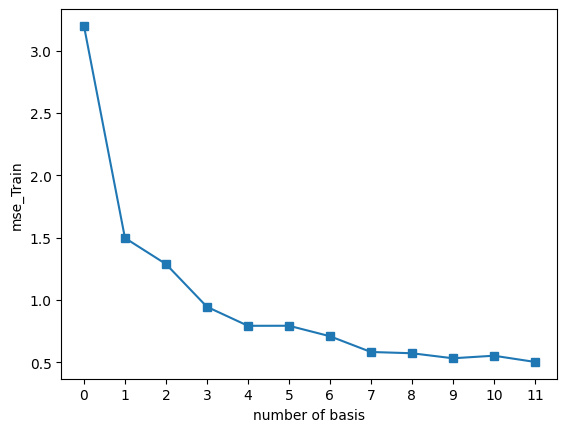

In [49]:
plt.plot(result_Train_mse,'s-')
plt.xticks(range(0,12))
plt.ylabel('mse_Train')
plt.xlabel('number of basis')

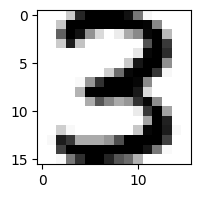

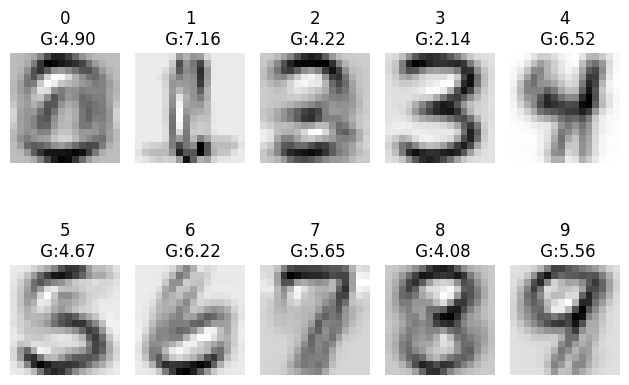

In [50]:
# 1. 找出第一張標籤為 3 的圖片
idx = np.where(y_Test == 3)[0][0]  # 取第一個索引
Z = x_Test[idx].reshape(16, 16)  # 圖片是16x16的
Z_inverted = 1-Z

plt.figure(figsize=(16, 8))

# 2. 顯示原始圖片
plot_image(Z)

# 3. 與每個數字計算重構並顯示
for d in range(10):
    # 取得該數字類別的因子矩陣和核心張量
    U1, U2, U3 = U_list[d]
    S = S_list[d]

    # 初始化重構矩陣
    Sigma = np.zeros((16, 16))

    # 使用前12個基底(j=0到11)進行重構
    for j in range(12):  # k = 12 意味著 j = 0 到 11
        if j < S.shape[2]:  # 確保不超出核心張量的大小
            Aj = U1.dot(S[:,:,j]).dot(U2.T)
            Cj = np.tensordot(Z, Aj)/np.tensordot(Aj, Aj)
            Sigma = Sigma + (Cj*Aj)
    Sigma = 1 - Sigma
    # 計算殘差
    residual = np.linalg.norm(Z_inverted - Sigma, "fro")

    # 顯示重構結果
    plt.subplot(2, 5, d+1)  # 從第2個位置開始顯示重構結果
    plt.imshow(Sigma, cmap='gray')
    plt.title(f'{d}\n G:{residual:.2f}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [51]:
result_Test_list, y_Test_predict, result_Test_predict, result_Test_residual, result_Test_mse = hosvdAlgorithm(x_Test, y_Test, S_list, U_list, 12)

In [52]:
result_Test_predict

0.9451918285999004

In [53]:
result_Test_list[result_Test_list['prediction'] != result_Test_list['actual']].shape

(110, 259)

In [54]:
result_Test_residual[2006]

array([5.04567401, 0.49802162, 4.35040819, 4.71675449, 2.93950785,
       4.39158541, 3.86829425, 4.18636629, 3.68506943, 3.60998211])

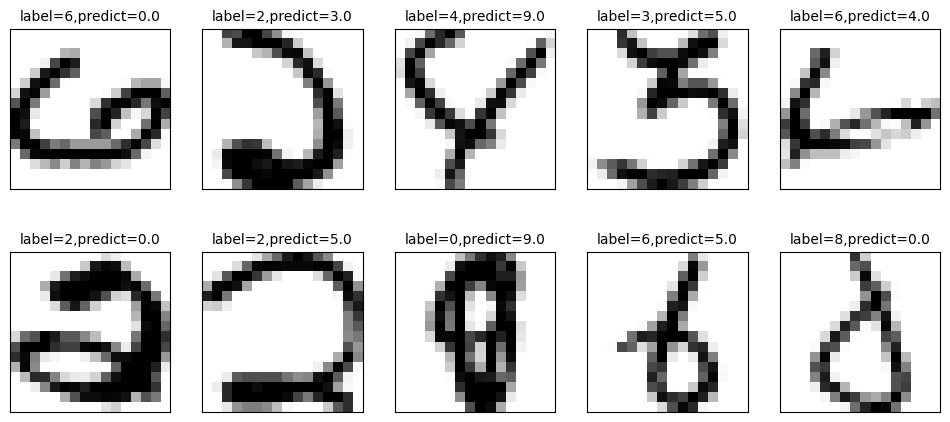

In [55]:
errorList = result_Test_list[result_Test_list['prediction'] != result_Test_list['actual']]

errorList.shape

plot_images_labels_prediction(errorList.iloc[:,np.arange(0, 256)], errorList.iloc[:,[256]], errorList.iloc[:,[257]],0,10)

In [89]:
totalCounts = result_Test_list[['actual']].groupby(['actual']).size().reset_index(name='totalCounts')
totalCounts = totalCounts.sort_values('actual', ascending=[True])
errorCounts = errorList[['actual']].groupby(['actual']).size().reset_index(name='errorCounts')
errorCounts = errorCounts.sort_values('actual', ascending=[True])
resultdf = pd.concat([totalCounts,pd.DataFrame(errorCounts, columns=['errorCounts'])], axis=1)
resultdf["successCounts"] = resultdf["totalCounts"]-resultdf["errorCounts"]
resultdf["probability"] = (resultdf["totalCounts"]-resultdf["errorCounts"])/resultdf["totalCounts"]
resultdf.sort_values('probability', ascending=[True])

,actual,totalCounts,errorCounts,successCounts,probability
3,3,166,22,144,0.867470
2,2,198,18,180,0.909091
5,5,160,13,147,0.918750
4,4,200,14,186,0.930000
8,8,166,11,155,0.933735
7,7,147,7,140,0.952381
9,9,177,8,169,0.954802
6,6,170,6,164,0.964706
1,1,264,6,258,0.977273
0,0,359,5,354,0.986072


In [90]:
temp = errorList[['actual', 'prediction']].groupby(['actual', 'prediction']).size().reset_index(name='counts')

errorPrediction = np.zeros((4, 10))

for i in range(0,10):
    errorPrediction[0][i] = temp[temp['actual'] == i].sort_values(['actual', 'counts'], ascending=[True, False]).iloc[0][1]
    errorPrediction[1][i] = temp[temp['actual'] == i].sort_values(['actual', 'counts'], ascending=[True, False]).iloc[0][2]
    errorPrediction[2][i] = temp[temp['actual'] == i].sort_values(['actual', 'counts'], ascending=[True, False]).iloc[1][1]
    errorPrediction[3][i] = temp[temp['actual'] == i].sort_values(['actual', 'counts'], ascending=[True, False]).iloc[1][2]

pd.DataFrame(errorPrediction, columns=np.arange(0, 10))

<ipython-input-90-fc441e2ff1fb>:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  errorPrediction[0][i] = temp[temp['actual'] == i].sort_values(['actual', 'counts'], ascending=[True, False]).iloc[0][1]
<ipython-input-90-fc441e2ff1fb>:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  errorPrediction[1][i] = temp[temp['actual'] == i].sort_values(['actual', 'counts'], ascending=[True, False]).iloc[0][2]
<ipython-input-90-fc441e2ff1fb>:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To acc

,0,1,2,3,4,5,6,7,8,9
0,2.0,4.0,0.0,5.0,9.0,3.0,0.0,4.0,0.0,1.0
1,2.0,3.0,8.0,13.0,5.0,4.0,2.0,3.0,3.0,4.0
2,4.0,6.0,4.0,8.0,1.0,9.0,4.0,1.0,3.0,4.0
3,2.0,3.0,3.0,4.0,3.0,3.0,2.0,1.0,3.0,3.0


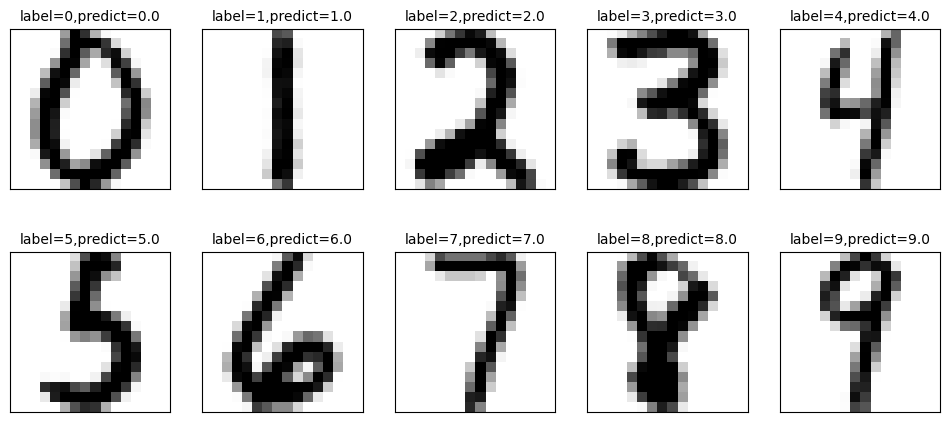

In [58]:
minList = result_Test_list[result_Test_list['actual'] == result_Test_list['prediction']].groupby('actual').agg({'residual': ['min']})


niceIndex = np.zeros(10)

for i in range(0,10):
    digitalList = result_Test_list[result_Test_list['actual'] == i]
    niceIndex[i] = int(digitalList[digitalList['residual'] == minList['residual']['min'][i]].index.values[0])

niceList = result_Test_list.iloc[result_Test_list.index.get_indexer(niceIndex)]

plot_images_labels_prediction(niceList.iloc[:,np.arange(0, 256)], niceList.iloc[:,[256]], niceList.iloc[:,[257]],0,10)

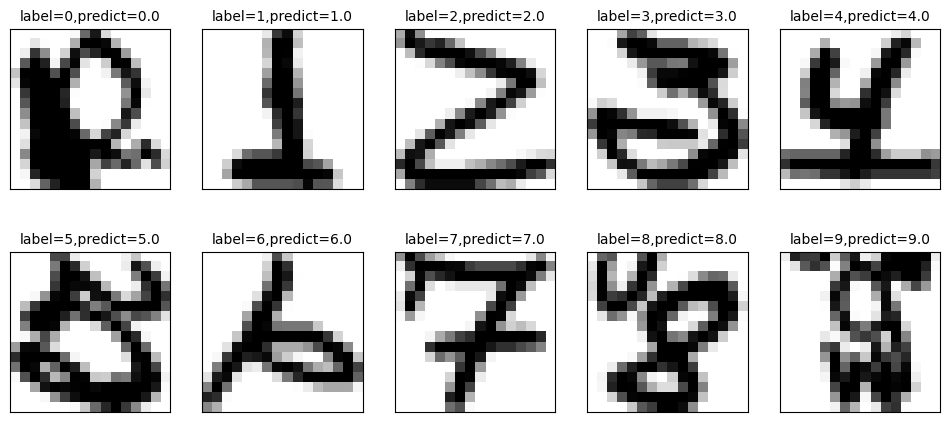

In [59]:
maxList = result_Test_list[result_Test_list['actual'] == result_Test_list['prediction']].groupby('actual').agg({'residual': ['max']})

uglyIndex = np.zeros(10)

for i in range(0,10):
    digitalList = result_Test_list[result_Test_list['actual'] == i]
    uglyIndex[i] = int(digitalList[digitalList['residual'] == maxList['residual']['max'][i]].index.values[0])

uglyList = result_Test_list.iloc[result_Test_list.index.get_indexer(uglyIndex)]

plot_images_labels_prediction(uglyList.iloc[:,np.arange(0, 256)], uglyList.iloc[:,[256]], uglyList.iloc[:,[257]],0,10)

In [60]:
result_Test_residual[2006]

array([5.04567401, 0.49802162, 4.35040819, 4.71675449, 2.93950785,
       4.39158541, 3.86829425, 4.18636629, 3.68506943, 3.60998211])

In [61]:
result_Test_mse

[np.float64(4.022421524663677),
 np.float64(2.0269058295964126),
 np.float64(1.8256103637269556),
 np.float64(1.4867962132536123),
 np.float64(1.2227204783258594),
 np.float64(1.2825112107623318),
 np.float64(1.1629297458893872),
 np.float64(1.1031390134529149),
 np.float64(1.0488290981564523),
 np.float64(0.9725959142999502),
 np.float64(0.9785749875435974),
 np.float64(0.9237668161434978)]

In [63]:
print("[", end = "")
for i in range(11):
  print(result_Test_mse[i], end = ",\n ")
print(result_Test_mse[11], end = "]")

[4.022421524663677,
 2.0269058295964126,
 1.8256103637269556,
 1.4867962132536123,
 1.2227204783258594,
 1.2825112107623318,
 1.1629297458893872,
 1.1031390134529149,
 1.0488290981564523,
 0.9725959142999502,
 0.9785749875435974,
 0.9237668161434978]

Text(0.5, 0, 'number of basis')

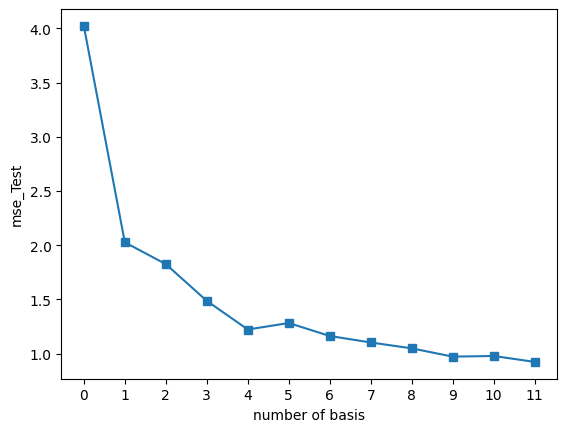

In [64]:
plt.plot(result_Test_mse,'s-')
plt.xticks(range(0,12))
plt.ylabel('mse_Test')
plt.xlabel('number of basis')

In [65]:
components = np.where(y_Test == 0)[0]
components
x_Test_0 = x_Test[components, :]
y_Test_0 = np.full(x_Test_0.shape[0],0)

In [66]:
result_Test_0_list, y_Test_0_predict, result_Test_0_predict, result_Test_0_residual, result_Test_0_mse = hosvdAlgorithm(x_Test_0, y_Test_0, S_list, U_list, 12)

In [67]:
result_Test_0_predict

0.9860724233983287

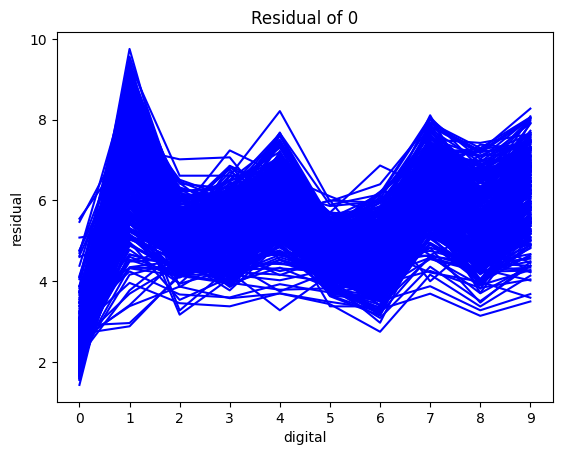

In [72]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
plt.title('Residual of 0')
for i in range(x_Test_0.shape[0]):
    plt.plot(result_Test_0_residual[i],color = 'blue')

In [69]:
components = np.where(y_Test == 1)[0]
components
x_Test_1 = x_Test[components, :]
y_Test_1 = np.full(x_Test_1.shape[0],1)

In [70]:
result_Test_1_list, y_Test_1_predict, result_Test_1_predict, result_Test_1_residual, result_Test_1_mse = hosvdAlgorithm(x_Test_1, y_Test_1, S_list, U_list, 12)

In [73]:
result_Test_1_predict

0.9772727272727273

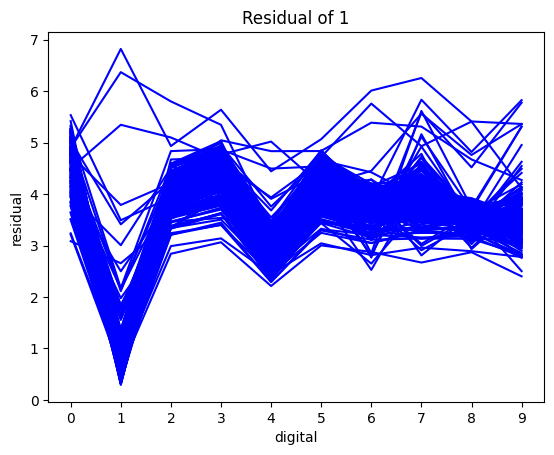

In [75]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
plt.title('Residual of 1')
for i in range(x_Test_1.shape[0]):
    plt.plot(result_Test_1_residual[i],color = 'blue')

In [76]:
components = np.where(y_Test == 2)[0]
components
x_Test_2 = x_Test[components, :]
y_Test_2 = np.full(x_Test_2.shape[0],2)

In [77]:
result_Test_2_list, y_Test_2_predict, result_Test_2_predict, result_Test_2_residual, result_Test_2_mse = hosvdAlgorithm(x_Test_2, y_Test_2, S_list, U_list, 12)

In [78]:
result_Test_2_predict

0.9090909090909091

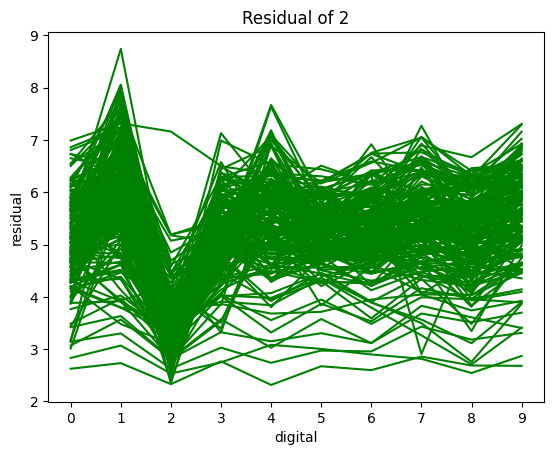

In [84]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
plt.title('Residual of 2')
for i in range(x_Test_2.shape[0]):
    plt.plot(result_Test_2_residual[i],color = 'green')

In [80]:
components = np.where(y_Test == 3)[0]
components
x_Test_3 = x_Test[components, :]
y_Test_3 = np.full(x_Test_3.shape[0],3)

In [81]:
result_Test_3_list, y_Test_3_predict, result_Test_3_predict, result_Test_3_residual, result_Test_3_mse = hosvdAlgorithm(x_Test_3, y_Test_3, S_list, U_list, 12)

In [82]:
result_Test_3_predict

0.8674698795180723

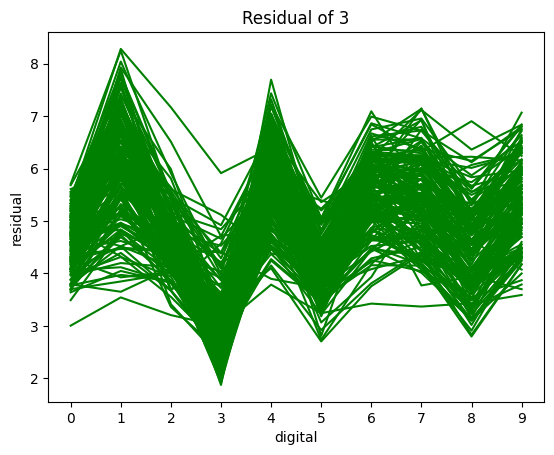

In [85]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
plt.title('Residual of 3')
for i in range(x_Test_3.shape[0]):
    plt.plot(result_Test_3_residual[i],color = 'green')

In [86]:
y_Student = np.array([0,1,2,3,4,5,6,7,8,9])
x_Student = np.zeros((10,256))

for i in range(10):
    img = Image.open("./digit/digit_s_" + str(i) +".JPG", "r").convert("L")
    img_array = 255 - np.array(img)
    x_Student[i,:] = np.array(img_array).flatten()

In [87]:
result_Student_list, y_Student_predict, result_Student_predict, result_Student_residual, result_Student_mse = hosvdAlgorithm(x_Student, y_Student, S_list, U_list, 12)
result_Student_predict

0.9

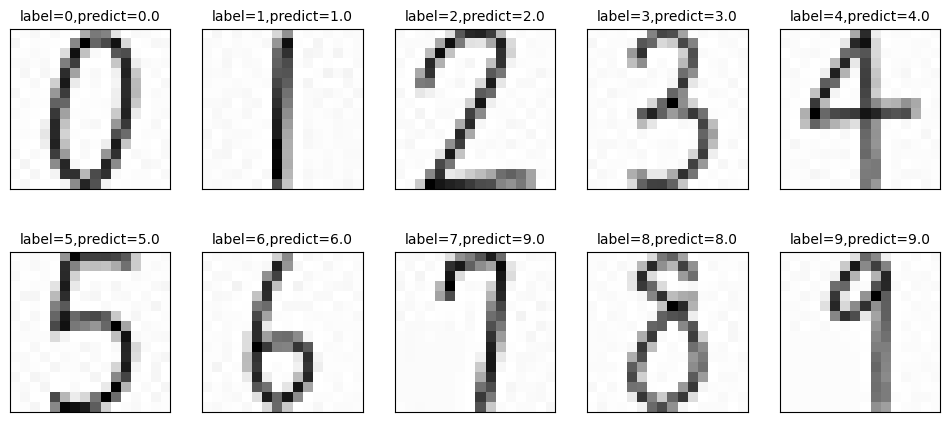

In [88]:
plot_images_labels_prediction(result_Student_list.iloc[:,np.arange(0, 256)], result_Student_list.iloc[:,[256]], result_Student_list.iloc[:,[257]],0,10)

# Classification Using CNN (卷積神經網路)

In [91]:
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from keras.utils import to_categorical

In [92]:
x_Train, y_Train, x_Test, y_Test = getUspDataSet("./input/usps.h5")
print("training set (16x16) : %d 張" % x_Train.shape[0])
print("testing set (16x16) : %d 張" % x_Test.shape[0])

training set (16x16) : 7291 張
testing set (16x16) : 2007 張


In [93]:
x_Train_tensor = x_Train.reshape(len(x_Train), 16, 16).astype('float32')
x_Test_tensor = x_Test.reshape(len(x_Test), 16, 16).astype('float32')

In [94]:
# 多加一個顏色的維度
x_Train4D=x_Train_tensor.reshape(x_Train_tensor.shape[0],16,16,1).astype('float32')
x_Test4D=x_Test_tensor.reshape(x_Test_tensor.shape[0],16,16,1).astype('float32')

In [95]:
# 把類別做Onehot encoding
y_TrainOneHot = to_categorical(y_Train)
y_TestOneHot = to_categorical(y_Test)

In [96]:
# define network structure

model = Sequential()

# initializing CNN

# 一個 Convolution Operation 搭配 一個 Pooling

# 二維卷積層 : filter為16, Kernel size為(5,5),Padding為(same)
model.add(Conv2D(filters=16,
                 kernel_size=(5,5),
                 padding='same',
                 input_shape=(16,16,1),
                 activation='relu'))

# MaxPooling size為(2,2)
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolutional layer

model.add(Conv2D(filters=36,
                 kernel_size=(5,5),
                 padding='same',
                 activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

# Drop掉部分神經元避免overfitting
model.add(Dropout(0.25))

# 平坦化
model.add(Flatten())

# Fully Connected Networks

model.add(Dense(units=256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=10,activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [97]:
# 訓練模型
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

train_history=model.fit(x=x_Train4D,
                        y=y_TrainOneHot,validation_split=0.2,
                        epochs=20, batch_size=300,verbose=2)

Epoch 1/20
20/20 - 4s - 221ms/step - accuracy: 0.4091 - loss: 1.7614 - val_accuracy: 0.8122 - val_loss: 0.8337
Epoch 2/20
20/20 - 5s - 268ms/step - accuracy: 0.7862 - loss: 0.6793 - val_accuracy: 0.9178 - val_loss: 0.2867
Epoch 3/20
20/20 - 3s - 146ms/step - accuracy: 0.8933 - loss: 0.3550 - val_accuracy: 0.9383 - val_loss: 0.1968
Epoch 4/20
20/20 - 2s - 111ms/step - accuracy: 0.9290 - loss: 0.2466 - val_accuracy: 0.9507 - val_loss: 0.1571
Epoch 5/20
20/20 - 2s - 112ms/step - accuracy: 0.9427 - loss: 0.1964 - val_accuracy: 0.9548 - val_loss: 0.1324
Epoch 6/20
20/20 - 2s - 118ms/step - accuracy: 0.9523 - loss: 0.1639 - val_accuracy: 0.9609 - val_loss: 0.1180
Epoch 7/20
20/20 - 3s - 127ms/step - accuracy: 0.9588 - loss: 0.1475 - val_accuracy: 0.9616 - val_loss: 0.1010
Epoch 8/20
20/20 - 3s - 170ms/step - accuracy: 0.9654 - loss: 0.1235 - val_accuracy: 0.9719 - val_loss: 0.0819
Epoch 9/20
20/20 - 2s - 118ms/step - accuracy: 0.9676 - loss: 0.1112 - val_accuracy: 0.9705 - val_loss: 0.0794
E

In [98]:
scores = model.evaluate(x_Test4D , y_TestOneHot)
scores[1]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9598 - loss: 0.1388


0.9586447477340698

In [99]:
y_Student = np.array([0,1,2,3,4,5,6,7,8,9])
x_Student = np.zeros((10,256))

for i in range(10):
    img = Image.open("./digit/digit_s_" + str(i) +".JPG", "r").convert("L")
    img_array = 255 - np.array(img)
    x_Student[i,:] = np.array(img_array).flatten()

In [100]:
x_Student_tensor = x_Student.reshape(len(x_Student), 16, 16).astype('float32')
x_Student4D=x_Student_tensor.reshape(x_Student_tensor.shape[0],16,16,1).astype('float32')
y_StudentOneHot = to_categorical(y_Student)

In [101]:
scores = model.evaluate(x_Student4D , y_StudentOneHot)
scores[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.0000e+00


1.0